In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Input

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/suryass2006-hue/datasets/refs/heads/main/image%20classification.csv"
)

print(df.head())
print(df.shape)

   7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.661  0.662  0.663  0.664  0.665  0.666  0.667  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(9999, 785)


In [4]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9999, 784)
y shape: (9999,)


In [5]:
X = X.reshape(-1, 28, 28, 1)

print(X.shape)

(9999, 28, 28, 1)


In [6]:
X = X / 255.0
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

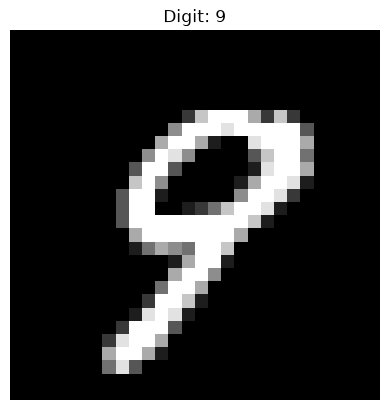

In [7]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title("Digit: " + str(y_train[0]))
plt.axis("off")
plt.show()

In [11]:
model = Sequential([
    
    Input(shape=(28, 28, 1)),
    
    Conv2D(32, (3, 3), activation="relu"),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation="relu"),
    
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation="relu"),
    
    Dense(10, activation="softmax")
])

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8233 - loss: 0.5834 - val_accuracy: 0.9475 - val_loss: 0.1986
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9572 - loss: 0.1344 - val_accuracy: 0.9688 - val_loss: 0.1255
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9754 - loss: 0.0809 - val_accuracy: 0.9762 - val_loss: 0.1147
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9817 - loss: 0.0548 - val_accuracy: 0.9700 - val_loss: 0.1116
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9844 - loss: 0.0452 - val_accuracy: 0.9800 - val_loss: 0.0906


In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test loss:" ,loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9725 - loss: 0.0915
Test Accuracy: 0.9725000262260437
Test loss: 0.0915021225810051


In [17]:
prediction = model.predict(X_test)

predicted_digit = np.argmax(prediction[0])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


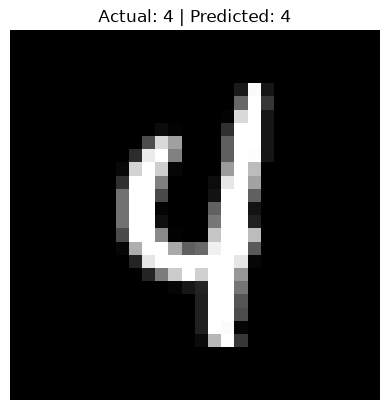

In [18]:
plt.imshow(X_test[0].reshape(28, 28), cmap="gray")

plt.title(
    f"Actual: {y_test[0]} | Predicted: {predicted_digit}"
)

plt.axis("off")
plt.show()